In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

import math
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import pandas as pd

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0
torchvision: 0.25.0


In [3]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def save_plot_loss(history: dict, title: str = "", save_path = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = torchvision.datasets.EMNIST(
    root="./data", train=True, download=True, transform=transform, split="balanced"
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", train=False, download=True, transform=transform, split="balanced"
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train size: 112800
test size: 18800


In [6]:
INPUT_DIM= 784 
NUM_CLASSES = 47

In [7]:
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype, x_batch.min(), x_batch.max())
print("y_batch:", y_batch.shape, y_batch.dtype, y_batch.min(), y_batch.max())

x_batch: torch.Size([64, 1, 28, 28]) torch.float32 tensor(-1.) tensor(1.)
y_batch: torch.Size([64]) torch.int64 tensor(0) tensor(46)


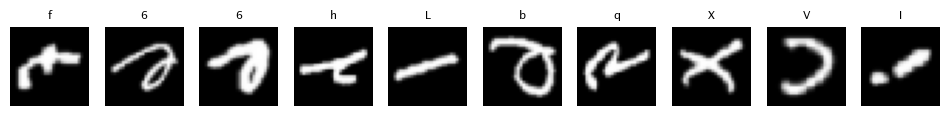

In [8]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [9]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [11]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [12]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.1388, acc=0.6641 | val loss=0.7445, acc=0.7713
epoch 02/20 | train loss=0.6635, acc=0.7863 | val loss=0.6413, acc=0.7957
epoch 03/20 | train loss=0.5651, acc=0.8117 | val loss=0.5648, acc=0.8215
epoch 04/20 | train loss=0.5120, acc=0.8268 | val loss=0.5847, acc=0.8083
epoch 05/20 | train loss=0.4753, acc=0.8361 | val loss=0.5210, acc=0.8343
epoch 06/20 | train loss=0.4488, acc=0.8443 | val loss=0.5235, acc=0.8308
epoch 07/20 | train loss=0.4258, acc=0.8493 | val loss=0.5303, acc=0.8284
epoch 08/20 | train loss=0.4125, acc=0.8514 | val loss=0.5279, acc=0.8314
epoch 09/20 | train loss=0.3969, acc=0.8572 | val loss=0.5128, acc=0.8330
epoch 10/20 | train loss=0.3816, acc=0.8628 | val loss=0.5536, acc=0.8277
epoch 11/20 | train loss=0.3694, acc=0.8647 | val loss=0.5244, acc=0.8361
epoch 12/20 | train loss=0.3576, acc=0.8682 | val loss=0.5202, acc=0.8378
epoch 13/20 | train loss=0.3495, acc=0.8704 | val loss=0.5498, acc=0.8321
epoch 14/20 | train loss=0.3378, acc=0

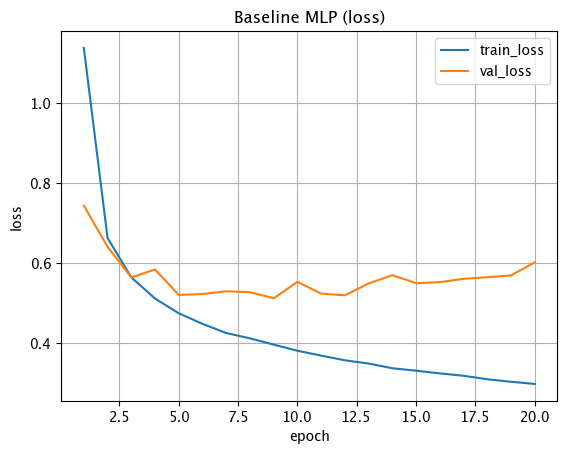

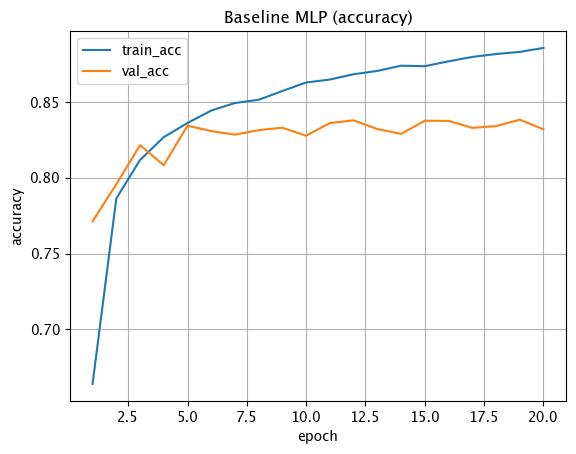

In [13]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=1.0557, acc=0.6793 | val loss=0.7312, acc=0.7580
epoch 02/20 | train loss=0.5999, acc=0.7997 | val loss=0.5791, acc=0.8110
epoch 03/20 | train loss=0.5146, acc=0.8229 | val loss=0.5460, acc=0.8203
epoch 04/20 | train loss=0.4616, acc=0.8383 | val loss=0.4967, acc=0.8340
epoch 05/20 | train loss=0.4283, acc=0.8477 | val loss=0.4979, acc=0.8319
epoch 06/20 | train loss=0.4018, acc=0.8548 | val loss=0.4941, acc=0.8355
epoch 07/20 | train loss=0.3791, acc=0.8611 | val loss=0.4918, acc=0.8425
epoch 08/20 | train loss=0.3583, acc=0.8668 | val loss=0.4886, acc=0.8490
epoch 09/20 | train loss=0.3414, acc=0.8706 | val loss=0.5104, acc=0.8403
epoch 10/20 | train loss=0.3300, acc=0.8745 | val loss=0.5177, acc=0.8390
epoch 11/20 | train loss=0.3164, acc=0.8787 | val loss=0.5249, acc=0.8473
epoch 12/20 | train loss=0.3076, acc=0.8823 | val loss=0.5233, acc=0.8381
epoch 13/20 | train loss=0.2977, acc=0.8852 | val loss=0.5435, acc=0.8362
epoch 14/20 | train loss=0.2886, acc=0

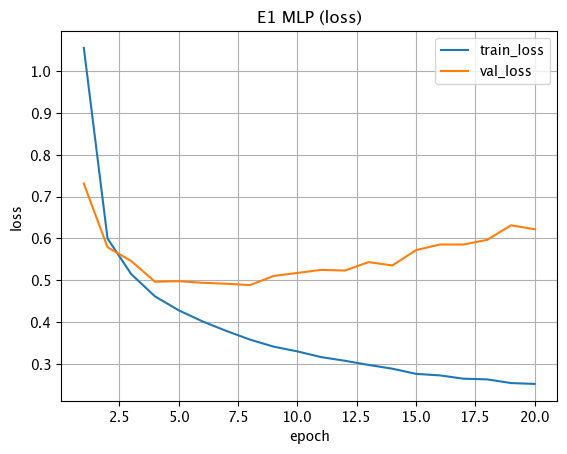

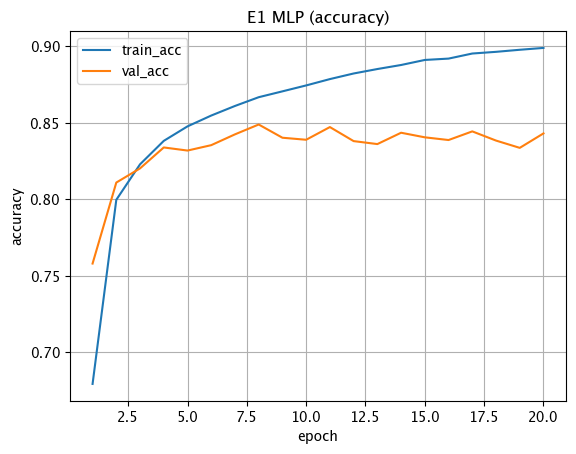

In [14]:
set_seed(42)
e1_model = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e1_model.parameters(), lr=1e-3)

history_e1_model = fit(
    e1_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e1_model, title="E1 MLP")

epoch 01/20 | train loss=1.4908, acc=0.5575 | val loss=0.8036, acc=0.7452
epoch 02/20 | train loss=0.9683, acc=0.6959 | val loss=0.6708, acc=0.7825
epoch 03/20 | train loss=0.8646, acc=0.7269 | val loss=0.6188, acc=0.7963
epoch 04/20 | train loss=0.8076, acc=0.7441 | val loss=0.5911, acc=0.8051
epoch 05/20 | train loss=0.7776, acc=0.7517 | val loss=0.5696, acc=0.8145
epoch 06/20 | train loss=0.7548, acc=0.7572 | val loss=0.5529, acc=0.8116
epoch 07/20 | train loss=0.7338, acc=0.7625 | val loss=0.5349, acc=0.8216
epoch 08/20 | train loss=0.7220, acc=0.7671 | val loss=0.5322, acc=0.8227
epoch 09/20 | train loss=0.7090, acc=0.7704 | val loss=0.5189, acc=0.8285
epoch 10/20 | train loss=0.7041, acc=0.7739 | val loss=0.5178, acc=0.8288
epoch 11/20 | train loss=0.6892, acc=0.7755 | val loss=0.4992, acc=0.8346
epoch 12/20 | train loss=0.6850, acc=0.7772 | val loss=0.5005, acc=0.8348
epoch 13/20 | train loss=0.6779, acc=0.7810 | val loss=0.5218, acc=0.8233
epoch 14/20 | train loss=0.6686, acc=0

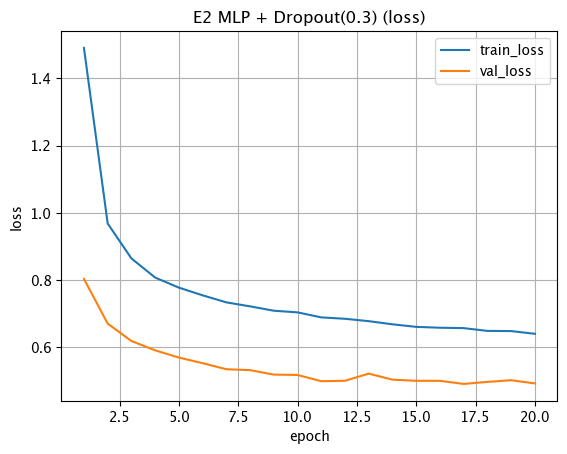

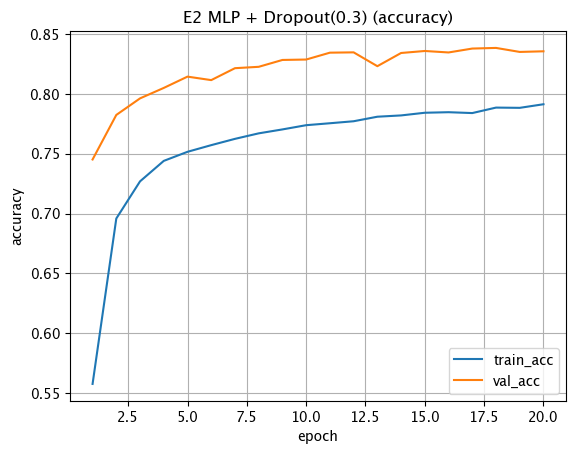

Dropout test: loss=0.4993, acc=0.8318


In [15]:
set_seed(42)
e2_model = MLP(hidden_dims=(512, 256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e2_model.parameters(), lr=1e-3)

history_e2 = fit(
    e2_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e2, title="E2 MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(e2_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=0.8269, acc=0.7530 | val loss=0.5457, acc=0.8189
epoch 02/20 | train loss=0.5017, acc=0.8272 | val loss=0.4731, acc=0.8407
epoch 03/20 | train loss=0.4315, acc=0.8480 | val loss=0.4526, acc=0.8419
epoch 04/20 | train loss=0.3876, acc=0.8611 | val loss=0.4243, acc=0.8578
epoch 05/20 | train loss=0.3563, acc=0.8694 | val loss=0.4337, acc=0.8522
epoch 06/20 | train loss=0.3301, acc=0.8768 | val loss=0.4149, acc=0.8593
epoch 07/20 | train loss=0.3079, acc=0.8842 | val loss=0.4220, acc=0.8582
epoch 08/20 | train loss=0.2884, acc=0.8885 | val loss=0.4215, acc=0.8643
epoch 09/20 | train loss=0.2734, acc=0.8932 | val loss=0.4186, acc=0.8645
epoch 10/20 | train loss=0.2605, acc=0.8970 | val loss=0.4297, acc=0.8631
epoch 11/20 | train loss=0.2465, acc=0.9013 | val loss=0.4168, acc=0.8653
epoch 12/20 | train loss=0.2356, acc=0.9061 | val loss=0.4450, acc=0.8583
epoch 13/20 | train loss=0.2265, acc=0.9082 | val loss=0.4429, acc=0.8598
epoch 14/20 | train loss=0.2193, acc=0

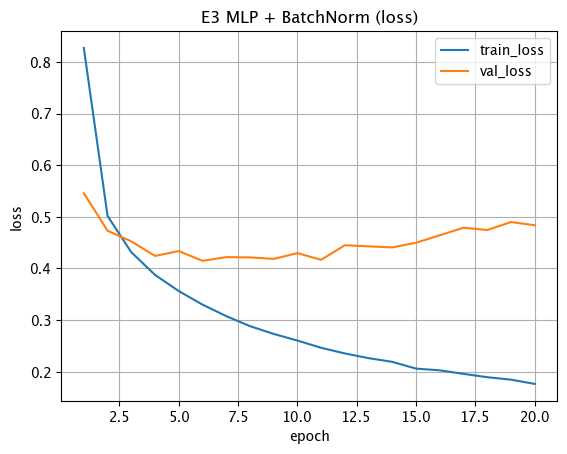

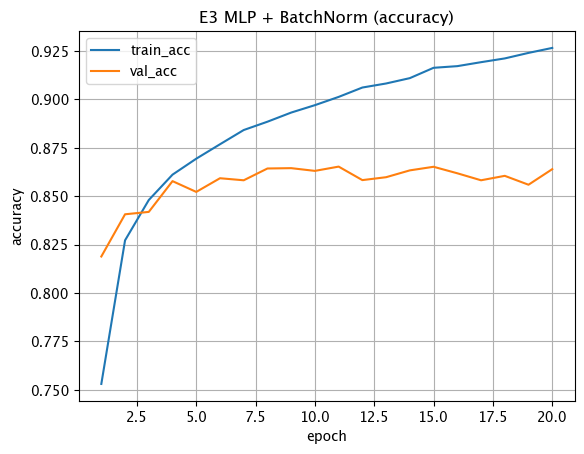

BatchNorm test: loss=0.5227, acc=0.8565


In [16]:
set_seed(42)
e3_model = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e3_model.parameters(), lr=1e-3)

history_e3 = fit(
    e3_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e3, title="E3 MLP + BatchNorm")
test_loss, test_acc = evaluate(e3_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/50 | train loss=0.8269, acc=0.7530 | val loss=0.5457, acc=0.8189
epoch 02/50 | train loss=0.5017, acc=0.8272 | val loss=0.4731, acc=0.8407
epoch 03/50 | train loss=0.4315, acc=0.8480 | val loss=0.4526, acc=0.8419
epoch 04/50 | train loss=0.3876, acc=0.8611 | val loss=0.4243, acc=0.8578
epoch 05/50 | train loss=0.3563, acc=0.8694 | val loss=0.4337, acc=0.8522
epoch 06/50 | train loss=0.3301, acc=0.8768 | val loss=0.4149, acc=0.8593
epoch 07/50 | train loss=0.3079, acc=0.8842 | val loss=0.4220, acc=0.8582
epoch 08/50 | train loss=0.2884, acc=0.8885 | val loss=0.4215, acc=0.8643
epoch 09/50 | train loss=0.2734, acc=0.8932 | val loss=0.4186, acc=0.8645
epoch 10/50 | train loss=0.2605, acc=0.8970 | val loss=0.4297, acc=0.8631
epoch 11/50 | train loss=0.2465, acc=0.9013 | val loss=0.4168, acc=0.8653
epoch 12/50 | train loss=0.2356, acc=0.9061 | val loss=0.4450, acc=0.8583
epoch 13/50 | train loss=0.2265, acc=0.9082 | val loss=0.4429, acc=0.8598
epoch 14/50 | train loss=0.2193, acc=0

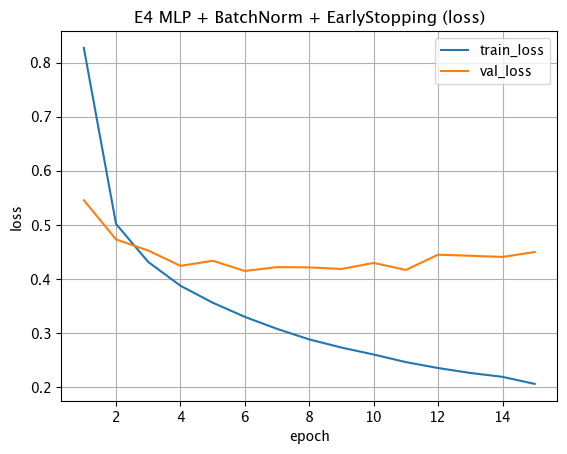

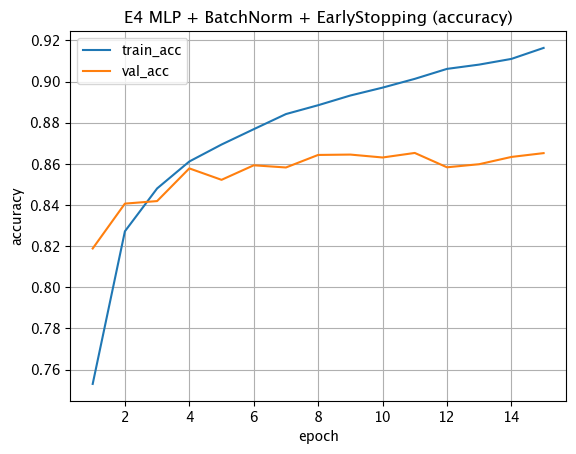

Combo test: loss=0.4503, acc=0.8598


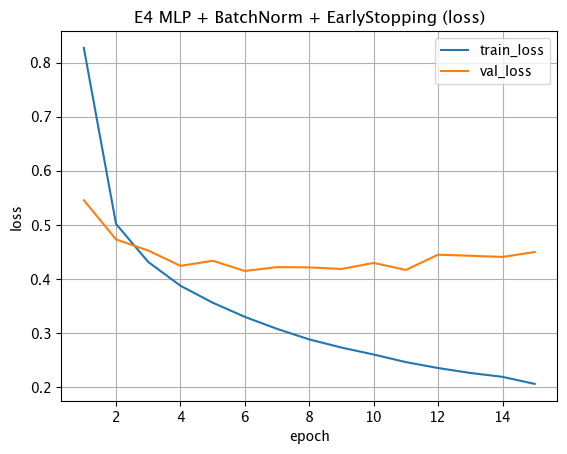

In [26]:
set_seed(42)
e4_model = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e4_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = fit(
    e4_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

torch.save(e4_model.state_dict(), "artifacts/best_model.pt")
plot_history(history_e4, title="E4 MLP + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")
save_plot_loss(history_e4, title="E4 MLP + BatchNorm + EarlyStopping", save_path="artifacts/figures/curves_best.png")

In [24]:
import json

config = {
    "model": {
        "architecture": "MLP",
        "hidden_dims": [512, 256, 128],
        "dropout_p": 0.0,
        "use_batchnorm": True
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "criterion": "CrossEntropyLoss",
        "epochs": 50,
        "early_stopping": {
            "patience": 4,
            "min_delta": 0.0005
        }
    },
    "seed": 42,
    "dataset": 'EMNIST'
}

config_path = "artifacts/best_config.json"
with open(config_path, 'w') as json_file:
    json.dump(config, json_file, indent=4)

print(f"Конфиг сохранен в {config_path}")

Конфиг сохранен в artifacts/best_config.json


epoch 01/6 | train loss=1.1701, acc=0.6458 | val loss=0.8807, acc=0.7204
epoch 02/6 | train loss=0.8132, acc=0.7431 | val loss=0.6899, acc=0.7832
epoch 03/6 | train loss=0.7353, acc=0.7663 | val loss=0.6481, acc=0.7947
epoch 04/6 | train loss=0.6780, acc=0.7825 | val loss=0.5929, acc=0.8041
epoch 05/6 | train loss=0.6317, acc=0.7938 | val loss=0.5706, acc=0.8151
epoch 06/6 | train loss=0.6049, acc=0.8020 | val loss=0.6244, acc=0.7997


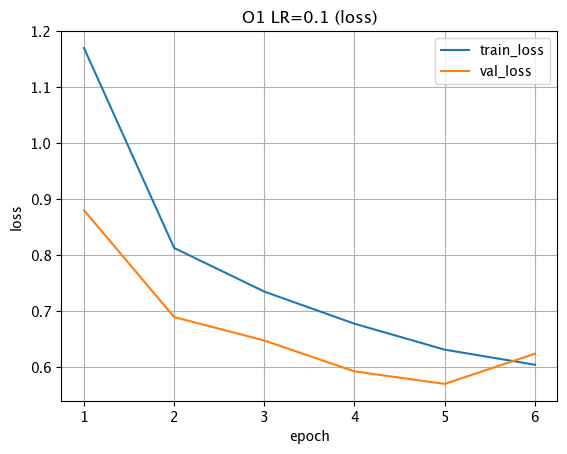

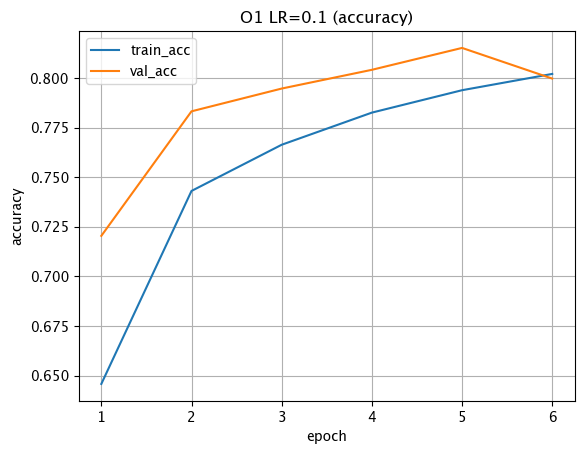

Combo test: loss=0.6372, acc=0.7947


In [ ]:
set_seed(42)
e4_model = MLP(hidden_dims=(512, 256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(e4_model.parameters(), lr=1e-1)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o1 = fit(
    e4_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_o1, title="O1 LR=0.1")
test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)

epoch 01/6 | train loss=0.5857, acc=0.7995 | val loss=0.6154, acc=0.8005
epoch 02/6 | train loss=0.5678, acc=0.8055 | val loss=0.5941, acc=0.8070
epoch 03/6 | train loss=0.5505, acc=0.8099 | val loss=0.5853, acc=0.8123
epoch 04/6 | train loss=0.5381, acc=0.8142 | val loss=0.5729, acc=0.8150
epoch 05/6 | train loss=0.5274, acc=0.8189 | val loss=0.5707, acc=0.8189
epoch 06/6 | train loss=0.5146, acc=0.8221 | val loss=0.5466, acc=0.8238


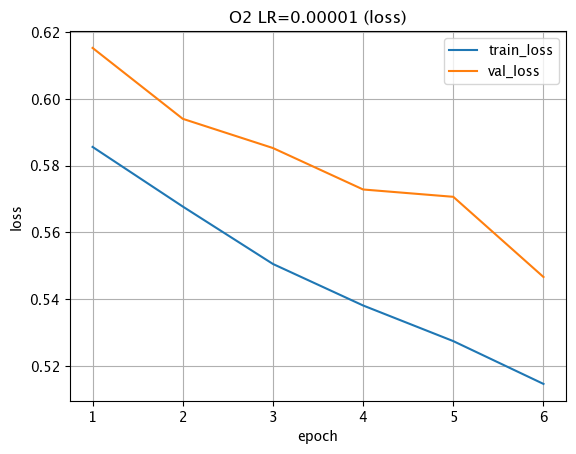

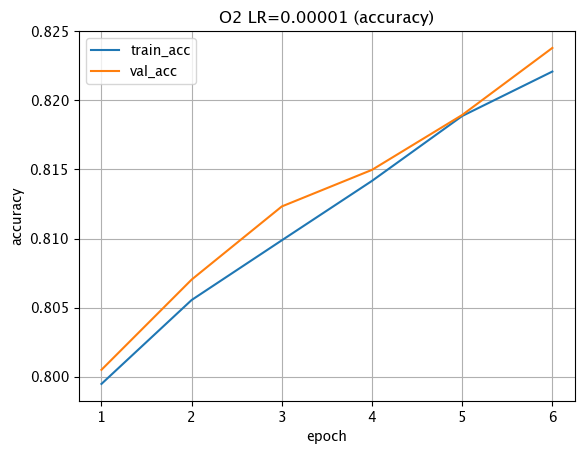

Combo test: loss=0.5604, acc=0.8172


In [ ]:
optimizer = optim.Adam(e4_model.parameters(), lr=1e-5)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o2 = fit(
    e4_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=6,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_o2, title="O2 LR=0.00001")
test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)

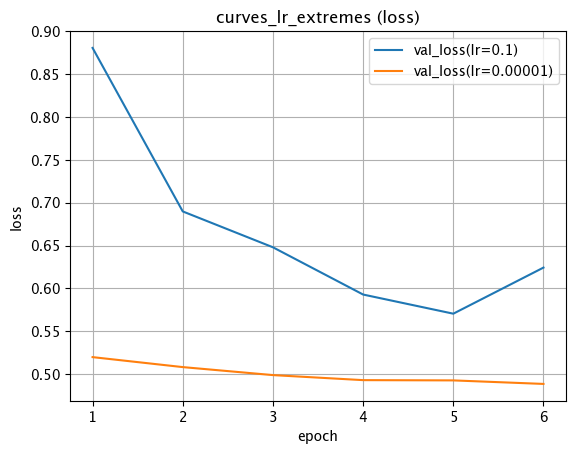

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def plot_two_graph(history1, history2, title="", save_path="") -> None:
    min_len = min(len(history1["val_loss"]), len(history2["val_loss"]))
    epochs = np.arange(1, min_len + 1)
    val_loss1 = history1["val_loss"][:min_len]
    val_loss2 = history2["val_loss"][:min_len]
    plt.figure()
    plt.plot(epochs, val_loss1, label="val_loss(lr=0.1)")
    plt.plot(epochs, val_loss2, label="val_loss(lr=0.00001)")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)

# Пример вызова
plot_two_graph(history_o1, history_o2, title="curves_lr_extremes", save_path="artifacts/figures/curves_lr_extremes.png")

epoch 01/15 | train loss=0.4725, acc=0.8370 | val loss=0.5199, acc=0.8345
epoch 02/15 | train loss=0.4570, acc=0.8436 | val loss=0.5083, acc=0.8379
epoch 03/15 | train loss=0.4503, acc=0.8445 | val loss=0.4989, acc=0.8401
epoch 04/15 | train loss=0.4466, acc=0.8452 | val loss=0.4931, acc=0.8416
epoch 05/15 | train loss=0.4448, acc=0.8453 | val loss=0.4928, acc=0.8407
epoch 06/15 | train loss=0.4434, acc=0.8462 | val loss=0.4887, acc=0.8435
epoch 07/15 | train loss=0.4427, acc=0.8465 | val loss=0.4886, acc=0.8424
epoch 08/15 | train loss=0.4392, acc=0.8479 | val loss=0.4876, acc=0.8422
epoch 09/15 | train loss=0.4393, acc=0.8475 | val loss=0.4927, acc=0.8423
epoch 10/15 | train loss=0.4369, acc=0.8486 | val loss=0.4848, acc=0.8435
EarlyStopping: остановка на эпохе 10. Лучший val_acc=0.8435


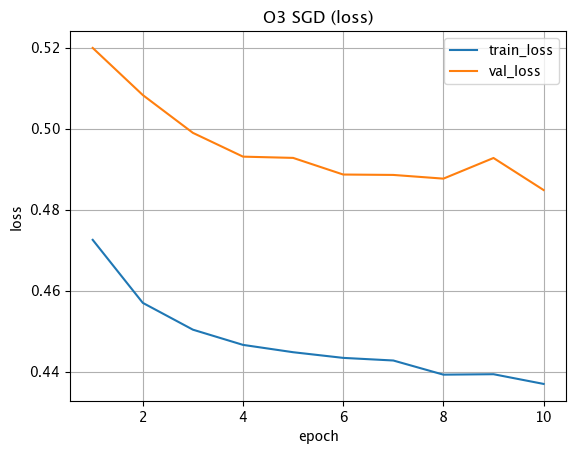

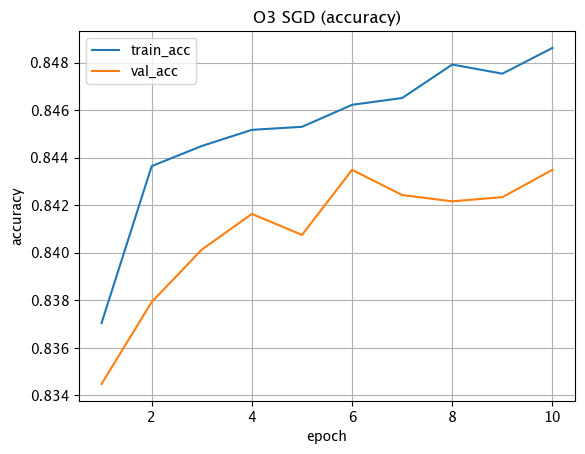

Combo test: loss=0.5014, acc=0.8354


In [ ]:
optimizer = optim.SGD(e4_model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_o2 = fit(
    e4_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_o2, title="O3 SGD")
test_loss, test_acc = evaluate(e4_model, test_loader, criterion, device)
print(f"o3 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [21]:
data = [
    ['E1', 'EMNIST', 42, '512-256-128 / ReLU / 0 / False', 'Adam', 0.001, 0, 0, 20, 0.8490, 0.4886],
    ['E2', 'EMNIST', 42, '512-256-128 / ReLU / 0.3 / False', 'Adam', 0.001, 0, 0, 20, 0.8375, 0.4972],
    ['E3', 'EMNIST', 42, '512-256-128 / ReLU / 0 / True', 'Adam', 0.001, 0, 0, 20, 0.8640, 0.4837],
    ['E4', 'EMNIST', 42, '512-256-128 / ReLU / 0 / True', 'Adam', 0.001, 0, 0, 20, 0.8653, 0.4168],
    ['O1', 'EMNIST', 42, '512-256-128 / ReLU / 0 / True', 'Adam', 0.1, 0, 0, 6, 0.8151, 0.5706],
    ['O2', 'EMNIST', 42, '512-256-128 / ReLU / 0 / True', 'Adam', 1e-5, 0, 0, 6, 0.8238, 0.5466],
    ['O3', 'EMNIST', 42, '512-256-128 / ReLU / 0 / True', 'SGD', 0.001, 0.9, 1e-4,15, 0.8435, 0.4848]
]

df = pd.DataFrame(data, columns=[
    'experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer',
    'lr', 'momentum', 'weight_decay', 'epochs_trained', 'best_val_accuracy', 'best_val_loss'
])

df.to_csv('artifacts/runs.csv', index=False)
